1. Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test splitting, and data visualization on a sample dataset.

# Import Libraries

In [1]:
import sys
print(sys.executable)

c:\Users\ThinkPad\anaconda3\envs\tf_env\python.exe


In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
train = pd.read_csv("dataset/fashion-mnist_train.csv")
test = pd.read_csv("dataset/fashion-mnist_test.csv")

print(train.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

# Separate Features and Labels

In [4]:
X_train = train.iloc[:,1:].values
y_train = train.iloc[:,0].values

X_test = test.iloc[:,1:].values
y_test = test.iloc[:,0].values

print(X_train.shape)
print(y_train.shape)

(60000, 784)
(60000,)


# Reshape Images

In [5]:
X_train = X_train.reshape(-1,28,28)
X_test = X_test.reshape(-1,28,28)

print(X_train.shape)

(60000, 28, 28)


# Visualize Dataset

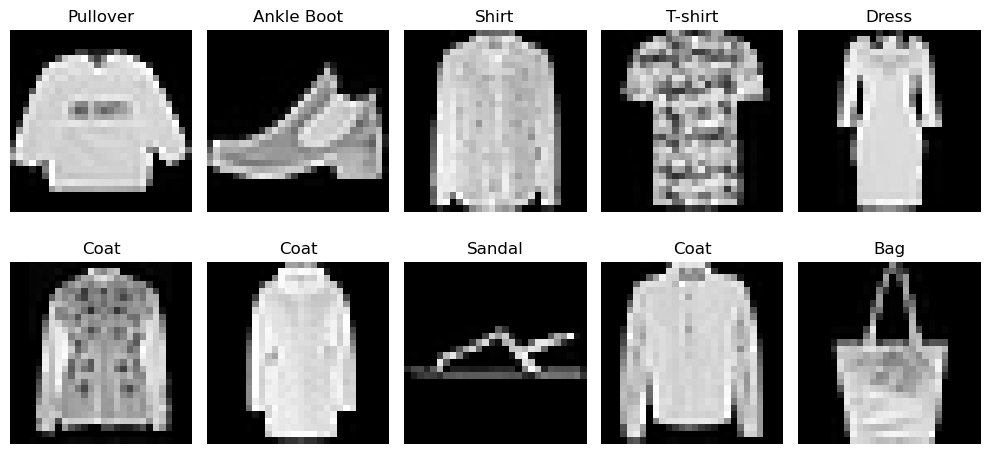

In [6]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Normalize Data

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


In [8]:
print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 60000
Testing Samples: 10000


# Build Neural Network

In [9]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

c:\Users\ThinkPad\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8206 - loss: 0.5146 - val_accuracy: 0.8468 - val_loss: 0.4383
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8612 - loss: 0.3874 - val_accuracy: 0.8547 - val_loss: 0.4087
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8714 - loss: 0.3520 - val_accuracy: 0.8737 - val_loss: 0.3603
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8821 - loss: 0.3238 - val_accuracy: 0.8777 - val_loss: 0.3460
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8867 - loss: 0.3050 - val_accuracy: 0.8800 - val_loss: 0.3319


# Evaluate Model

In [12]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Loss :",loss)
print("Accuracy :",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8841 - loss: 0.3196
Loss : 0.31956300139427185
Accuracy : 0.8841000199317932


# Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: T-shirt
Actual: T-shirt


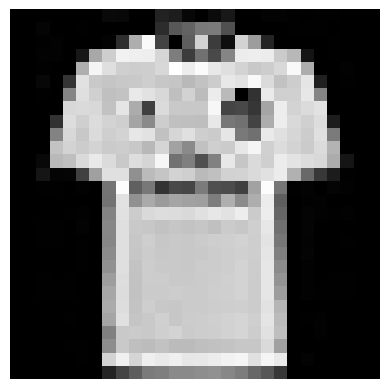

In [13]:
pred = model.predict(X_test)

print("Predicted:",class_names[np.argmax(pred[0])])
print("Actual:",class_names[y_test[0]])

plt.imshow(X_test[0], cmap='gray')
plt.axis('off')
plt.show()

# Accuracy Visualization

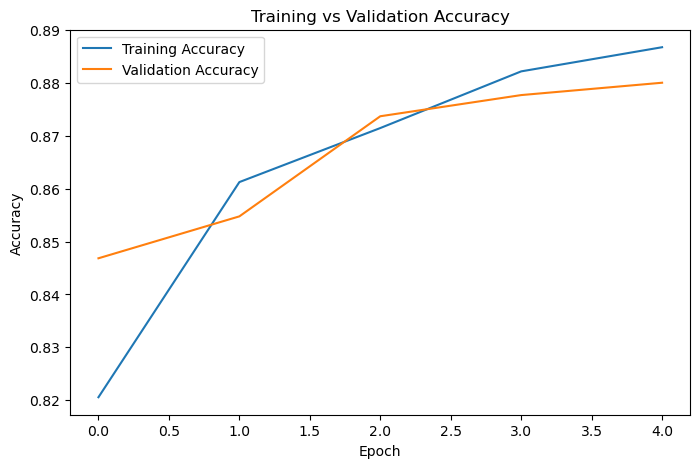

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()